# Raw and Processed Wafer Images

This notebook exports a raw wafer map and the corresponding CNN input image for use in the presentation.

The preprocessing matches the experiment notebooks:

- nearest-neighbor resize to **56 × 56**;
- one channel dimension;
- discrete rescaling from **0, 1, 2** to **0, 0.5, 1**.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from matplotlib.colors import BoundaryNorm, ListedColormap
from skimage.transform import resize

In [2]:
def find_repository_root():
    current_path = Path.cwd().resolve()

    for candidate in (current_path, *current_path.parents):
        if (
            (candidate / "project").is_dir()
            and (candidate / "datasets").is_dir()
            and (candidate / "scripts").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Repository root not found. Expected the folders "
        "'project', 'datasets', and 'scripts'."
    )


REPO_ROOT = find_repository_root()
DATASET_PATH = REPO_ROOT / "datasets" / "Dataset.pkl"

OUTPUT_DIR = (
    REPO_ROOT
    / "presentation_outputs"
    / "figures"
    / "preprocessing"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print(f"Repository root: {REPO_ROOT}")
print(f"Dataset: {DATASET_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

Repository root: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects
Dataset: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\datasets\Dataset.pkl
Output directory: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\presentation_outputs\figures\preprocessing


## Configuration

Choose the wafer class and the sample position within that class.

In [3]:
SAMPLE_CLASS = "scratch"
SAMPLE_POSITION = 0

TARGET_SHAPE = (56, 56)

PRESENTATION_COLORS = {
    "background": "#33271D",
    "normal": "#70876C",
    "defective": "#D4A413",
    "text": "#33271D",
}

## Load the cleaned dataset

In [4]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATASET_PATH}\n"
        "Run scripts/Cleaned_dataset_creation.py first."
    )

df = pd.read_pickle(DATASET_PATH)

required_columns = {
    "waferMap",
    "failureType",
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise KeyError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

if not df["failureType"].map(
    lambda value: isinstance(value, str)
).all():
    raise TypeError(
        "Dataset.pkl is not cleaned. Run "
        "scripts/Cleaned_dataset_creation.py first."
    )

available_classes = sorted(
    df["failureType"].unique()
)

if SAMPLE_CLASS not in available_classes:
    raise ValueError(
        f"Unknown class {SAMPLE_CLASS!r}. "
        f"Available classes: {available_classes}"
    )

class_samples = df.loc[
    df["failureType"] == SAMPLE_CLASS
].reset_index(drop=True)

if not 0 <= SAMPLE_POSITION < len(class_samples):
    raise IndexError(
        f"SAMPLE_POSITION must be between 0 and "
        f"{len(class_samples) - 1} for class {SAMPLE_CLASS!r}."
    )

sample_row = class_samples.iloc[SAMPLE_POSITION]

raw_wafer = np.asarray(
    sample_row["waferMap"],
    dtype=np.uint8,
)

print(f"Selected class: {SAMPLE_CLASS}")
print(f"Class samples: {len(class_samples):,}")
print(f"Original shape: {raw_wafer.shape}")
print(f"Original values: {np.unique(raw_wafer)}")

Selected class: scratch
Class samples: 1,193
Original shape: (53, 58)
Original values: [0 1 2]


## Apply the CNN preprocessing

In [5]:
resized_wafer = resize(
    raw_wafer,
    output_shape=TARGET_SHAPE,
    order=0,
    preserve_range=True,
    anti_aliasing=False,
).astype(np.uint8)

cnn_input = np.expand_dims(
    resized_wafer,
    axis=-1,
).astype(np.float32)

cnn_input *= 0.5

print(f"Resized shape: {resized_wafer.shape}")
print(f"CNN input shape: {cnn_input.shape}")
print(f"Resized discrete values: {np.unique(resized_wafer)}")
print(f"CNN input values: {np.unique(cnn_input)}")

Resized shape: (56, 56)
CNN input shape: (56, 56, 1)
Resized discrete values: [0 1 2]
CNN input values: [0.  0.5 1. ]


## Presentation palette

In [6]:
raw_colormap = ListedColormap(
    [
        PRESENTATION_COLORS["background"],
        PRESENTATION_COLORS["normal"],
        PRESENTATION_COLORS["defective"],
    ]
)

raw_norm = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5],
    raw_colormap.N,
)

processed_colormap = ListedColormap(
    [
        PRESENTATION_COLORS["background"],
        PRESENTATION_COLORS["normal"],
        PRESENTATION_COLORS["defective"],
    ]
)

processed_norm = BoundaryNorm(
    [-0.25, 0.25, 0.75, 1.25],
    processed_colormap.N,
)

## Export the raw wafer image

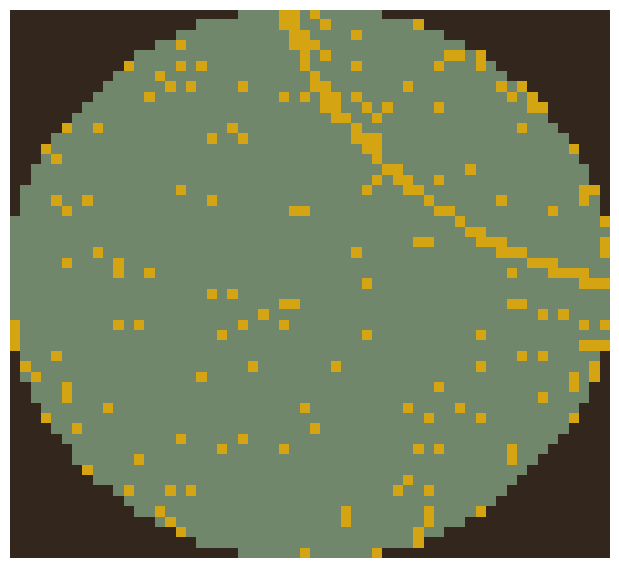

Raw wafer image saved to: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\presentation_outputs\figures\preprocessing\scratch_raw_wafer.png


In [7]:
raw_output_path = (
    OUTPUT_DIR
    / f"{SAMPLE_CLASS}_raw_wafer.png"
)

figure, axis = plt.subplots(figsize=(6, 6))

axis.imshow(
    raw_wafer,
    cmap=raw_colormap,
    norm=raw_norm,
    interpolation="nearest",
)

axis.axis("off")
figure.patch.set_alpha(0)
axis.set_facecolor("none")

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.savefig(
    raw_output_path,
    dpi=300,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0,
)

plt.show()

print(f"Raw wafer image saved to: {raw_output_path}")

## Export the processed CNN input

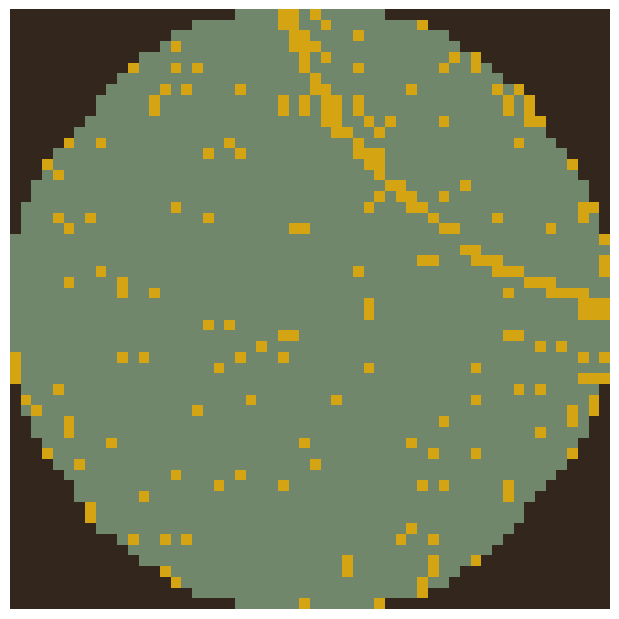

Processed CNN input image saved to: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\presentation_outputs\figures\preprocessing\scratch_cnn_input.png


In [8]:
processed_output_path = (
    OUTPUT_DIR
    / f"{SAMPLE_CLASS}_cnn_input.png"
)

figure, axis = plt.subplots(figsize=(6, 6))

axis.imshow(
    np.squeeze(cnn_input),
    cmap=processed_colormap,
    norm=processed_norm,
    interpolation="nearest",
)

axis.axis("off")
figure.patch.set_alpha(0)
axis.set_facecolor("none")

plt.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.savefig(
    processed_output_path,
    dpi=300,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0,
)

plt.show()

print(
    "Processed CNN input image saved to: "
    f"{processed_output_path}"
)

## Optional side-by-side comparison

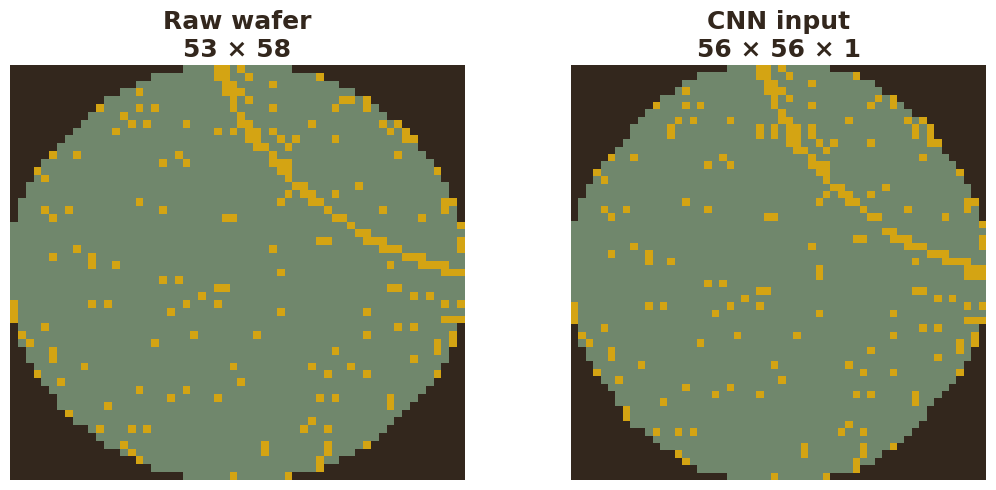

Comparison image saved to: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\presentation_outputs\figures\preprocessing\scratch_preprocessing_comparison.png


In [ ]:
comparison_output_path = (
    OUTPUT_DIR
    / f"{SAMPLE_CLASS}_preprocessing_comparison.png"
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 5),
)

axes[0].imshow(
    raw_wafer,
    cmap=raw_colormap,
    norm=raw_norm,
    interpolation="nearest",
)
axes[0].set_title(
    f"Raw wafer\n{raw_wafer.shape[0]} × {raw_wafer.shape[1]}",
    color=PRESENTATION_COLORS["text"],
    fontsize=18,
    fontweight="bold",
)
axes[0].axis("off")

axes[1].imshow(
    np.squeeze(cnn_input),
    cmap=processed_colormap,
    norm=processed_norm,
    interpolation="nearest",
)
axes[1].set_title(
    "CNN input\n56 × 56 × 1",
    color=PRESENTATION_COLORS["text"],
    fontsize=18,
    fontweight="bold",
)
axes[1].axis("off")

figure.patch.set_alpha(0)

for axis in axes:
    axis.set_facecolor("none")

plt.tight_layout()

plt.savefig(
    comparison_output_path,
    dpi=300,
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.05,
)

plt.show()

print(
    "Comparison image saved to: "
    f"{comparison_output_path}"
)

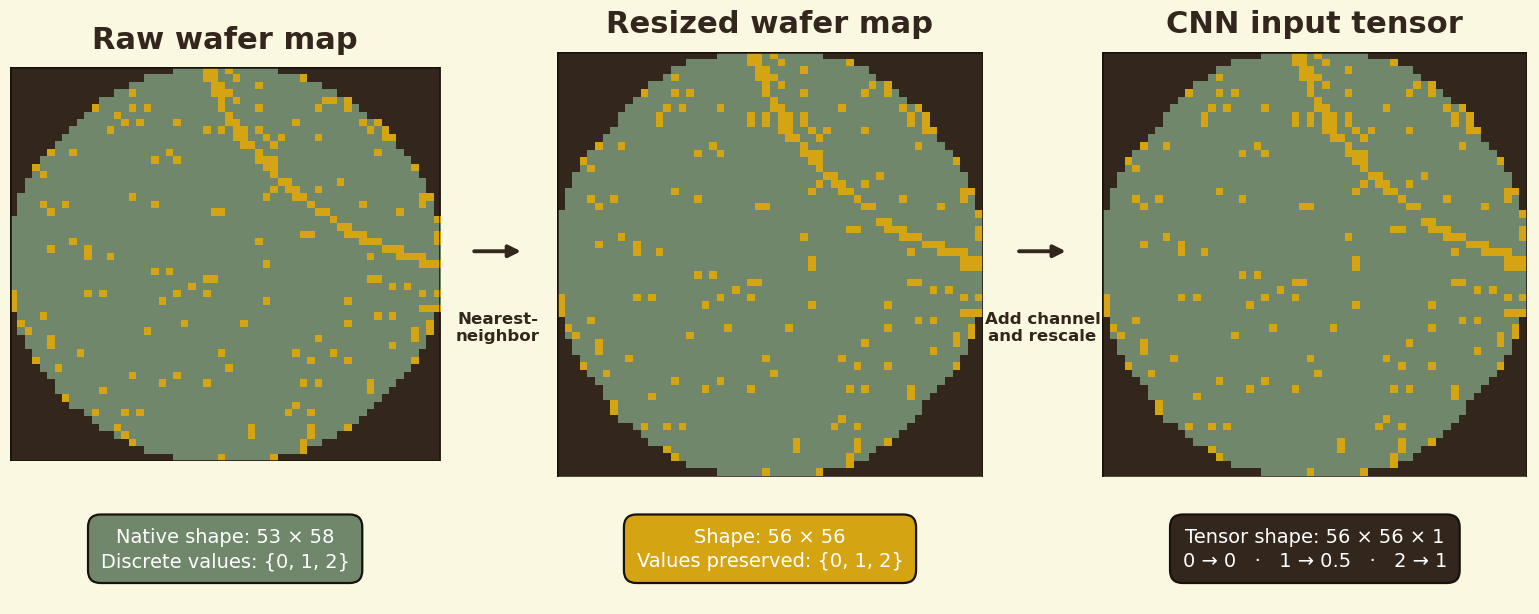

Presentation-ready preprocessing image saved to: C:\Users\lollo\Documents\GitHub\deep-learning-wafer-defects\presentation_outputs\figures\preprocessing\scratch_preprocessing_comparison.png


In [12]:
from matplotlib.patches import Rectangle


comparison_output_path = (
    OUTPUT_DIR
    / f"{SAMPLE_CLASS}_preprocessing_comparison.png"
)

SLIDE_BACKGROUND = "#FBF8E1"
TEXT_COLOR = "#33271D"
BORDER_COLOR = "#17120E"
SAGE = "#70876C"
GOLD = "#D4A413"


figure = plt.figure(
    figsize=(16, 6.5),
    facecolor=SLIDE_BACKGROUND,
)

grid = figure.add_gridspec(
    nrows=2,
    ncols=5,
    width_ratios=[1, 0.16, 1, 0.16, 1],
    height_ratios=[1, 0.25],
    wspace=0.08,
    hspace=0.08,
)


# Image axes
raw_axis = figure.add_subplot(grid[0, 0])
first_arrow_axis = figure.add_subplot(grid[0, 1])
resized_axis = figure.add_subplot(grid[0, 2])
second_arrow_axis = figure.add_subplot(grid[0, 3])
cnn_axis = figure.add_subplot(grid[0, 4])

# Caption axes
raw_caption_axis = figure.add_subplot(grid[1, 0])
resized_caption_axis = figure.add_subplot(grid[1, 2])
cnn_caption_axis = figure.add_subplot(grid[1, 4])


def style_image_axis(axis, title):
    axis.set_title(
        title,
        fontsize=22,
        fontweight="bold",
        color=TEXT_COLOR,
        pad=14,
    )

    axis.axis("off")
    axis.set_facecolor(SLIDE_BACKGROUND)

    # Thin frame around each wafer image
    frame = Rectangle(
        (0, 0),
        1,
        1,
        transform=axis.transAxes,
        fill=False,
        linewidth=1.8,
        edgecolor=BORDER_COLOR,
    )

    axis.add_patch(frame)


def draw_pipeline_arrow(axis, label):
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.axis("off")

    axis.annotate(
        "",
        xy=(0.88, 0.53),
        xytext=(0.12, 0.53),
        arrowprops={
            "arrowstyle": "-|>",
            "linewidth": 2.8,
            "color": TEXT_COLOR,
            "mutation_scale": 18,
        },
    )

    axis.text(
        0.5,
        0.39,
        label,
        ha="center",
        va="top",
        fontsize=12,
        fontweight="bold",
        color=TEXT_COLOR,
    )


def style_caption_axis(axis, text, fill_color):
    axis.axis("off")

    axis.text(
        0.5,
        0.52,
        text,
        ha="center",
        va="center",
        fontsize=14,
        color="white",
        linespacing=1.35,
        bbox={
            "boxstyle": "round,pad=0.65",
            "facecolor": fill_color,
            "edgecolor": BORDER_COLOR,
            "linewidth": 1.6,
        },
    )


# Raw wafer
raw_axis.imshow(
    raw_wafer,
    cmap=raw_colormap,
    norm=raw_norm,
    interpolation="nearest",
)

style_image_axis(
    raw_axis,
    "Raw wafer map",
)

style_caption_axis(
    raw_caption_axis,
    (
        f"Native shape: "
        f"{raw_wafer.shape[0]} × {raw_wafer.shape[1]}\n"
        "Discrete values: {0, 1, 2}"
    ),
    SAGE,
)


# Resized wafer
resized_axis.imshow(
    resized_wafer,
    cmap=raw_colormap,
    norm=raw_norm,
    interpolation="nearest",
)

style_image_axis(
    resized_axis,
    "Resized wafer map",
)

style_caption_axis(
    resized_caption_axis,
    (
        "Shape: 56 × 56\n"
        "Values preserved: {0, 1, 2}"
    ),
    GOLD,
)


# Final CNN input
cnn_axis.imshow(
    np.squeeze(cnn_input),
    cmap=processed_colormap,
    norm=processed_norm,
    interpolation="nearest",
)

style_image_axis(
    cnn_axis,
    "CNN input tensor",
)

style_caption_axis(
    cnn_caption_axis,
    (
        "Tensor shape: 56 × 56 × 1\n"
        "0 → 0   ·   1 → 0.5   ·   2 → 1"
    ),
    TEXT_COLOR,
)


# Transformation arrows
draw_pipeline_arrow(
    first_arrow_axis,
    "Nearest-\nneighbor",
)

draw_pipeline_arrow(
    second_arrow_axis,
    "Add channel\nand rescale",
)


plt.subplots_adjust(
    left=0.025,
    right=0.975,
    top=0.92,
    bottom=0.07,
)

plt.savefig(
    comparison_output_path,
    dpi=300,
    facecolor=SLIDE_BACKGROUND,
    transparent=False,
    bbox_inches="tight",
    pad_inches=0.12,
)

plt.show()

print(
    "Presentation-ready preprocessing image saved to: "
    f"{comparison_output_path}"
)

## Generated files

In [10]:
generated_files = pd.DataFrame(
    {
        "Image": [
            "Raw wafer",
            "Processed CNN input",
            "Side-by-side comparison",
        ],
        "Path": [
            raw_output_path.relative_to(
                REPO_ROOT
            ).as_posix(),
            processed_output_path.relative_to(
                REPO_ROOT
            ).as_posix(),
            comparison_output_path.relative_to(
                REPO_ROOT
            ).as_posix(),
        ],
        "Exists": [
            raw_output_path.exists(),
            processed_output_path.exists(),
            comparison_output_path.exists(),
        ],
    }
)

display(generated_files)

,Image,Path,Exists
0,Raw wafer,presentation_outputs/figures/preprocessing/scr...,True
1,Processed CNN input,presentation_outputs/figures/preprocessing/scr...,True
2,Side-by-side comparison,presentation_outputs/figures/preprocessing/scr...,True
